<h4>Setup</h4>

In [1]:
import QuantLib as ql

In [2]:
today = ql.Date(7,ql.March, 2014)
ql.Settings.instance().evaluationDate = today

<h4>The Instrument</h4>

As a sample instrument, we’ll take a textbook example: a European option.

In [4]:
option= ql.EuropeanOption(ql.PlainVanillaPayoff(ql.Option.Call, 100.0),
                          ql.EuropeanExercise(ql.Date(7, ql.June, 2014)))

<b>First pricing method: analytic Black-Scholes formula</b>

In [5]:
u = ql.SimpleQuote(100.0)
r = ql.SimpleQuote(0.01)
sigma = ql.SimpleQuote(0.20)

First we build flat curves for the risk-free rate and the volatility...

In [6]:
riskFreeCurve = ql.FlatForward(0, ql.TARGET(),
                               ql.QuoteHandle(r), ql.Actual360())
volatility = ql.BlackConstantVol(0, ql.TARGET(),
                                ql.QuoteHandle(sigma), ql.Actual360())
                               

...then we instantiate the process with the underlying value and the curves we just built.

In [7]:
process = ql.BlackScholesProcess(ql.QuoteHandle(u),
                                 ql.YieldTermStructureHandle(riskFreeCurve),
                                 ql.BlackVolTermStructureHandle(volatility))

Once we have the process, we can finally use it to build the engine...

In [9]:
engine = ql.AnalyticEuropeanEngine(process)

...and once we have the engine, we can set it to the option and evaluate the latter.

In [10]:
option.setPricingEngine(engine)

In [11]:
print(option.NPV())

4.155543462156206


Depending on the instrument and the engine, we can also ask for other results; in this case, we can
ask for Greeks.

In [12]:
print(option.delta())
print(option.gamma())
print(option.vega())

0.5302223303784392
0.03934493301271913
20.109632428723106


<b>Market changes</b>

In [13]:
u.setValue(105.0)
print(option.NPV())

7.27556357927846


In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

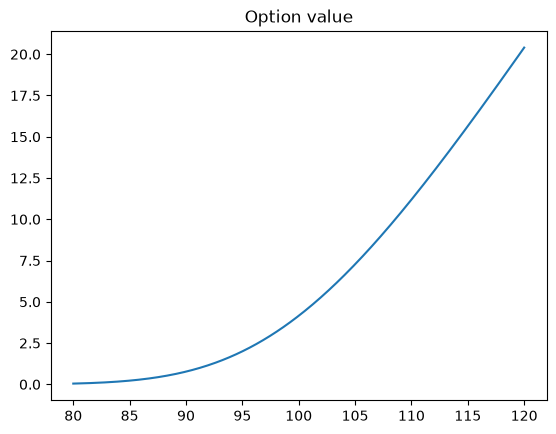

In [15]:
xs = np.linspace(80.0, 120.0, 400)
ys=[]
for x in xs:
    u.setValue(x)
    ys.append(option.NPV())
plt.title('Option value')
plt.plot(xs, ys)
plt.show()

Other market data also affect the value, of course.

In [17]:
u.setValue(105.0)
r.setValue(0.01)
sigma.setValue(0.20)

In [18]:
print(option.NPV())

7.27556357927846


We can see it when we change the risk-free rate...

In [19]:
r.setValue(0.03)

In [20]:
print(option.NPV())

7.624029148527754


...or the volatility.

In [21]:
sigma.setValue(0.25)

In [22]:
print(option.NPV())

8.531296969971573


<b>Date changes</b>

Just as it does when inputs are modified, the value also changes if we advance the evaluation date.

In [23]:
u.setValue(105.0)
r.setValue(0.01)
sigma.setValue(0.20)
print(option.NPV())

7.27556357927846


...and then move to a date two months before exercise.

In [24]:
ql.Settings.instance().evaluationDate=ql.Date(7, ql.April, 2014)

In [25]:
print(option.NPV())

6.560073820974377


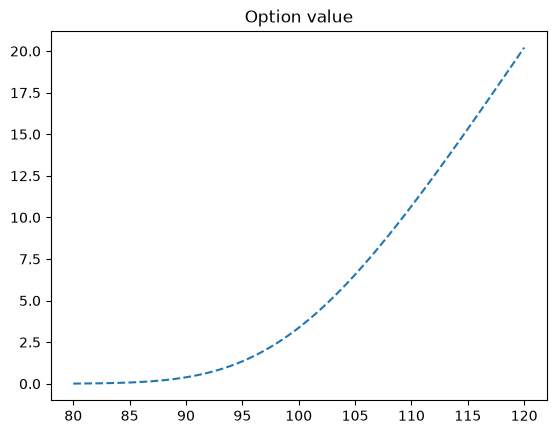

In [27]:
xs = np.linspace(80.0, 120.0, 400)
ys=[]
for x in xs:
    u.setValue(x)
    ys.append(option.NPV())
plt.title('Option value')
plt.plot(xs, ys,'--')
plt.show()

Reset the default evaluationDate

In [29]:
ql.Settings.instance().evaluationDate = ql.Date(7, ql.June, 2014)

In [30]:
print(option.NPV())

0.0


<b>Other pricing methods</b>

In [31]:
today = ql.Date(7, ql.March, 2014)
ql.Settings.instance().evaluationDate = today
u.setValue(105.0)
r.setValue(0.01)
sigma.setValue(0.20)

use a Heston model to price the option.

In [33]:
model = ql.HestonModel(
    ql.HestonProcess(
        ql.YieldTermStructureHandle(riskFreeCurve),
        ql.YieldTermStructureHandle(ql.FlatForward(0, ql.TARGET(),
                                                  0.0, ql.Actual360())),
        ql.QuoteHandle(u),
        0.04, 0.1, 0.01, 0.05, -0.75))

...pass it to the corresponding engine, and set the new engine to the option.

In [34]:
engine = ql.AnalyticHestonEngine(model)
option.setPricingEngine(engine)

In [35]:
print(option.NPV())

7.295356086978634


<b>Lazy recalculation</b>

avoid recalculations when nothing has changed.<br/>
Switch to Monte Carlo engine

In [36]:
engine = ql.MCEuropeanEngine(process, "PseudoRandom",
                            timeSteps=20,
                            requiredSamples= 250000)
option.setPricingEngine(engine)

In [37]:
%time print(option.NPV())

7.281974586820704
CPU times: user 1.33 s, sys: 0 ns, total: 1.33 s
Wall time: 1.33 s


In [38]:
u.setValue(104.0)

...the option is notified of the change, and the next call to NPV will again take a while.

In [39]:
%time print(option.NPV())

6.573164076819481
CPU times: user 1.35 s, sys: 0 ns, total: 1.35 s
Wall time: 1.36 s
